In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Real estate.csv')

In [ ]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.tail()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5
413,414,2013.500,6.5,90.45606,9,24.97433,121.54310,63.9


In [ ]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


<Axes: >

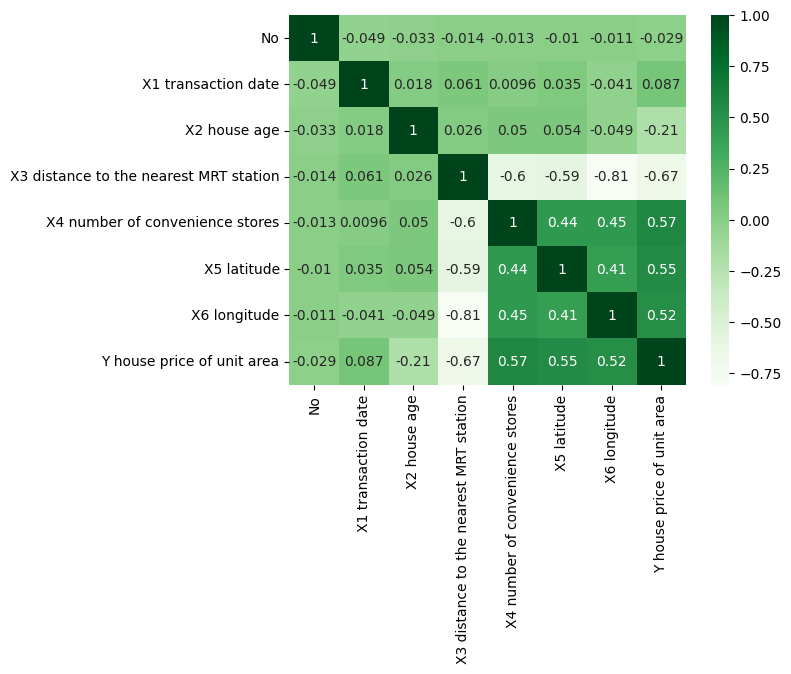

In [ ]:
sns.heatmap(df.corr(),annot=True, cmap="Greens")

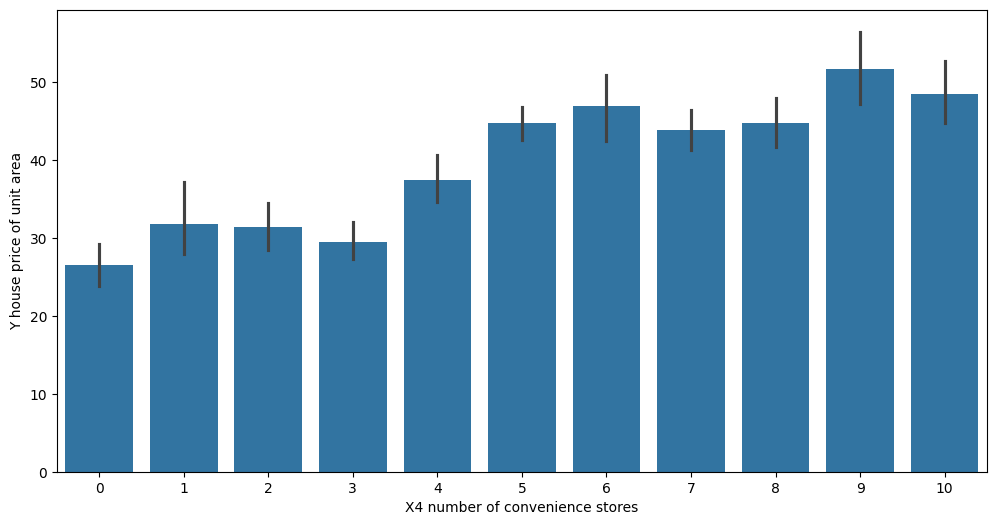

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='X4 number of convenience stores', y='Y house price of unit area', data=df)
plt.show()

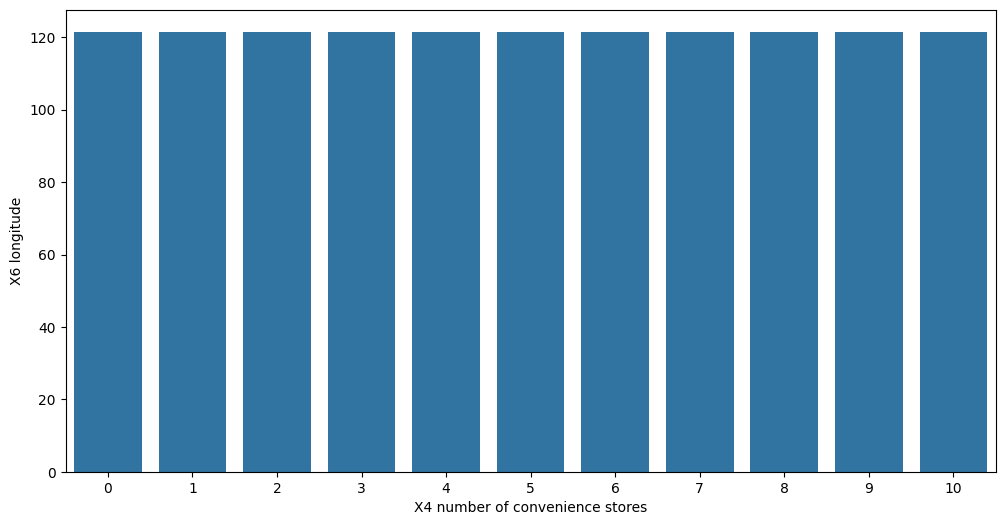

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='X4 number of convenience stores', y='X6 longitude', data=df)
plt.show()

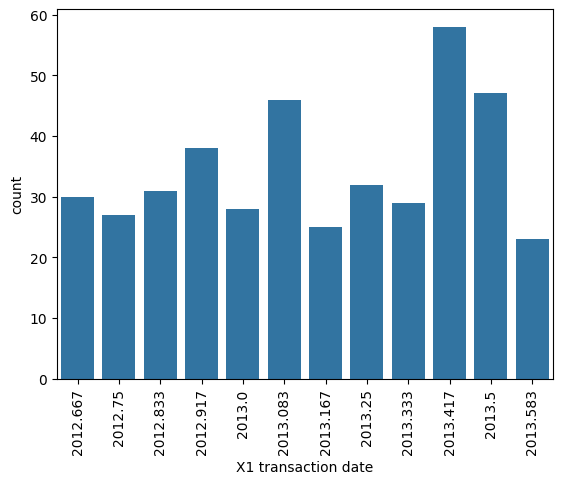

In [ ]:
Countplot_date=sns.countplot(data=df, x='X1 transaction date')
plt.setp(Countplot_date.get_xticklabels(), rotation=90)
plt.show()

<Axes: xlabel='X2 house age', ylabel='Y house price of unit area'>

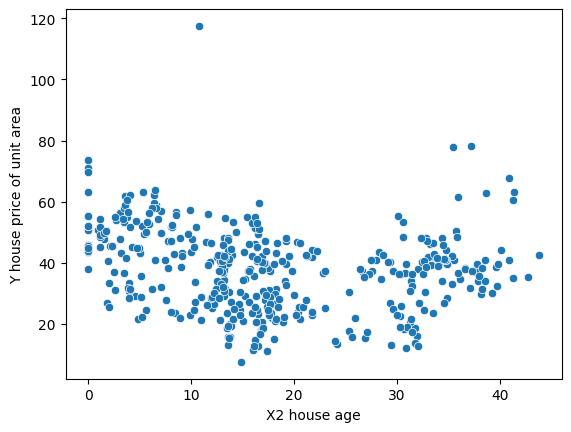

In [ ]:
sns.scatterplot(data=df, x='X2 house age'  ,y='Y house price of unit area')

## Detemine Features & Labels

In [ ]:
X=df.drop('Y house price of unit area',axis=1)
y=df['Y house price of unit area']

## Split Data to Train & Test

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
poly_features=polynomial_converter.fit_transform(X)
X_train , X_test , y_train , y_test=train_test_split( poly_features, y,test_size=0.3, random_state=101)

## Train Model

In [ ]:
from sklearn.linear_model import LinearRegression
polymodel=LinearRegression()
polymodel.fit(X_train , y_train)

LinearRegression()

## Predicting Test Data

In [ ]:
y_pred=polymodel.predict(X_test)
pd.DataFrame({'y_test':y_test,'y_pred':y_pred,'Residuals':(y_test-y_pred)}).head(8)

,y_test,y_pred,Residuals
176,19.2,16.382290,2.817710
347,11.2,3.929467,7.270533
307,24.7,17.438173,7.261827
299,46.1,47.146074,-1.046074
391,31.3,27.340929,3.959071
212,31.1,33.198376,-2.098376
104,30.5,35.522555,-5.022555
311,42.2,38.089539,4.110461


## Adjusting Model Parameters

In [ ]:
from sklearn import metrics
#create train list RMSE per degree
train_RMSE_list=[]
#create test list RMSE per degree
test_RMSE_list=[]

for d in range(1,10):
    #create poly dataset for degree(d)
    polynomial_converter=PolynomialFeatures(degree=d, include_bias=False)
    poly_features=polynomial_converter.fit_transform(X)

    #train & test dataset
    X_train , X_test , y_train , y_test = train_test_split(poly_features, y, test_size=0.3)

    #train model
    polymodel=LinearRegression()
    polymodel.fit(X_train , y_train)

    #predicting
    y_train_pred=polymodel.predict(X_train)
    y_test_pred=polymodel.predict(X_test)

    #evaluating model
    train_RMSE=np.sqrt(metrics.mean_squared_error(y_train , y_train_pred))

    test_RMSE=np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))

    #Append to RMSE to the train & test list
    train_RMSE_list.append(train_RMSE)
    test_RMSE_list.append(test_RMSE)

In [ ]:
MAE_poly=metrics.mean_absolute_error(y_test,y_pred)
MSE_poly=metrics.mean_squared_error(y_test,y_pred)
RMSE_poly=np.sqrt(MSE_poly)
pd.DataFrame([MAE_poly ,MSE_poly, RMSE_poly],index=['MAE','MSE','RMSE'],columns=['metrics'])

,metrics
MAE,14.245122
MSE,322.967194
RMSE,17.971288


In [ ]:
train_RMSE_list

[7.76872332942008,
 5.86483831943602,
 6.660014728012915,
 4.980170065784873,
 1.8035365577261406,
 1.4468601120924434,
 0.4061927129105576,
 2.2753240118266578,
 1.6792187872879507]

In [ ]:
test_RMSE_list

[10.880317988917964,
 10.404370660945919,
 10.92871431414299,
 90.51685842856915,
 1411.8254359064374,
 888.0938418325657,
 29779.664356408408,
 1269802.330113065,
 6459237.42048546]

## Plot Polynomial Degree vs RMSE

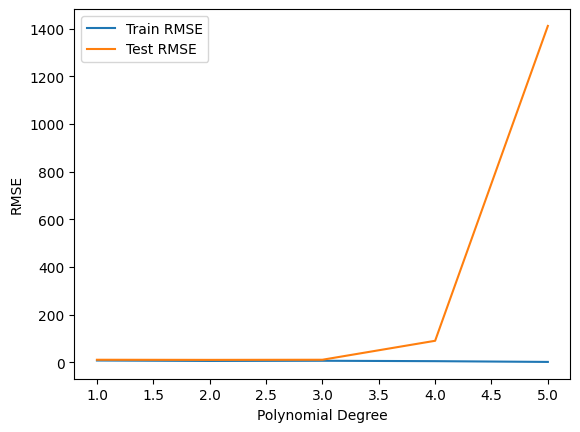

In [ ]:

plt.plot(range(1,6) , train_RMSE_list[:5], label='Train RMSE')
plt.plot(range(1,6) , test_RMSE_list[:5], label='Test RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.legend()

It seems degree= 2 is the best choice for model.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn import metrics

In [ ]:
# Fit polynomial regression
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

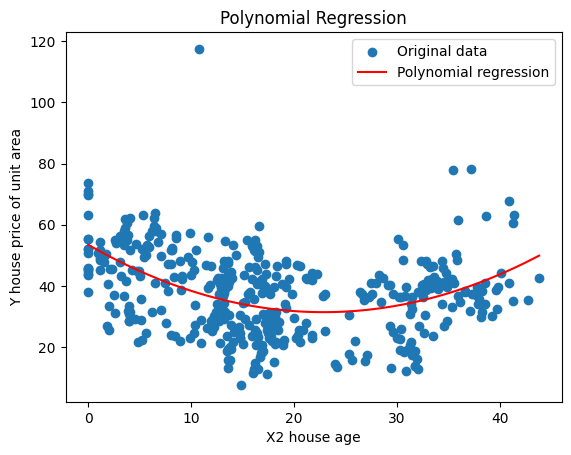

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv("Real estate.csv")

# Assuming you want to predict house prices based on a single feature, say 'X1'
X = df[['X2 house age']].values
y = df['Y house price of unit area'].values

# Fit polynomial regression
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# Visualize the polynomial regression
X_new = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)

plt.scatter(X, y, label='Original data')
plt.plot(X_new, y_new, color='red', label='Polynomial regression')
plt.xlabel('X2 house age')
plt.ylabel('Y house price of unit area')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

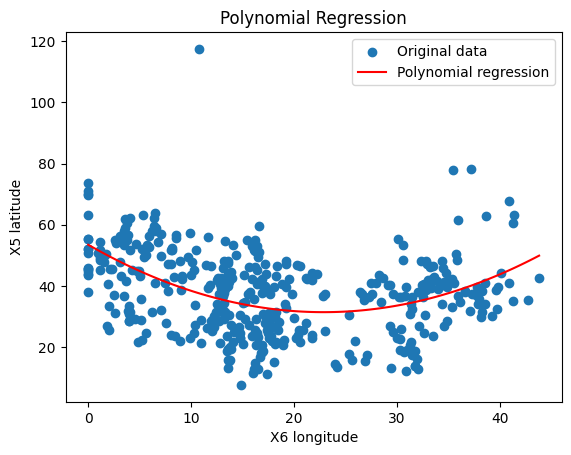

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv("Real estate.csv")

# Assuming you want to predict house prices based on a single feature, say 'X1'
X = df[['X2 house age']].values
y = df['Y house price of unit area'].values

# Fit polynomial regression
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# Visualize the polynomial regression
X_new = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)

plt.scatter(X, y, label='Original data')
plt.plot(X_new, y_new, color='red', label='Polynomial regression')
plt.xlabel('X6 longitude')
plt.ylabel('X5 latitude')
plt.title('Polynomial Regression')
plt.legend()
plt.show()